# Sales Performance Analysis

This notebook analyzes the analytics-ready sales dataset to identify key revenue trends, customer purchasing behavior, product performance, market opportunities, and operational risks.

The analysis focuses on answering business questions and translating the findings into actionable recommendations.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
import pandas as pd
import numpy as np

from config.paths import ANALYTICS_SALES_FILE

from utils.file_utils import read_csv

In [3]:
sales_df = read_csv(ANALYTICS_SALES_FILE)

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,InvoiceYear,...,MonthName,Quarter,MonthStart,YearMonth,OrderType,InvoiceRevenue,BasketSize,CustomerType,PurchaseFrequency,RepeatCustomer
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,...,December,Q4,2010-12-01,Dec-2010,Sale,139.12,7,Registered Customer,34.0,Repeat Customer
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,...,December,Q4,2010-12-01,Dec-2010,Sale,139.12,7,Registered Customer,34.0,Repeat Customer
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,...,December,Q4,2010-12-01,Dec-2010,Sale,139.12,7,Registered Customer,34.0,Repeat Customer
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,...,December,Q4,2010-12-01,Dec-2010,Sale,139.12,7,Registered Customer,34.0,Repeat Customer
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,...,December,Q4,2010-12-01,Dec-2010,Sale,139.12,7,Registered Customer,34.0,Repeat Customer


In [4]:
sales_df.shape

(534593, 21)

In [5]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534593 entries, 0 to 534592
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   InvoiceNo          534593 non-null  object 
 1   StockCode          534593 non-null  object 
 2   Description        534593 non-null  object 
 3   Quantity           534593 non-null  int64  
 4   InvoiceDate        534593 non-null  object 
 5   UnitPrice          534593 non-null  float64
 6   CustomerID         401598 non-null  float64
 7   Country            534593 non-null  object 
 8   Revenue            534593 non-null  float64
 9   InvoiceYear        534593 non-null  int64  
 10  InvoiceMonth       534593 non-null  int64  
 11  MonthName          534593 non-null  object 
 12  Quarter            534593 non-null  object 
 13  MonthStart         534593 non-null  object 
 14  YearMonth          534593 non-null  object 
 15  OrderType          534593 non-null  object 
 16  In

In [6]:
sales_df["InvoiceDate"] = pd.to_datetime(
    sales_df["InvoiceDate"],
    format="%Y-%m-%d %H:%M:%S"
)

In [7]:
sales_df["CustomerID"] = (
    sales_df["CustomerID"]
    .astype("Int64")
)

In [8]:
sales_df["MonthStart"] = pd.to_datetime(
    sales_df["MonthStart"]
)

In [9]:
sales_df["PurchaseFrequency"] = (
    sales_df["PurchaseFrequency"]
    .astype("Int64")
)

In [10]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 534593 entries, 0 to 534592
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   InvoiceNo          534593 non-null  object        
 1   StockCode          534593 non-null  object        
 2   Description        534593 non-null  object        
 3   Quantity           534593 non-null  int64         
 4   InvoiceDate        534593 non-null  datetime64[ns]
 5   UnitPrice          534593 non-null  float64       
 6   CustomerID         401598 non-null  Int64         
 7   Country            534593 non-null  object        
 8   Revenue            534593 non-null  float64       
 9   InvoiceYear        534593 non-null  int64         
 10  InvoiceMonth       534593 non-null  int64         
 11  MonthName          534593 non-null  object        
 12  Quarter            534593 non-null  object        
 13  MonthStart         534593 non-null  datetime

In [11]:
line_level_columns = [
    "Quantity",
    "UnitPrice",
    "Revenue",
]

line_level_stats = (
    sales_df[line_level_columns]
    .describe()
    .T
)

line_level_stats

,count,mean,std,min,25%,50%,75%,max
Quantity,534593.0,9.959769,217.103446,-80995.0,1.00,3.0,10.00,80995.0
UnitPrice,534593.0,4.691788,95.038019,0.0,1.25,2.1,4.13,38970.0
Revenue,534593.0,18.234678,380.780408,-168469.6,3.75,9.9,17.46,168469.6


In [12]:
# distribuion

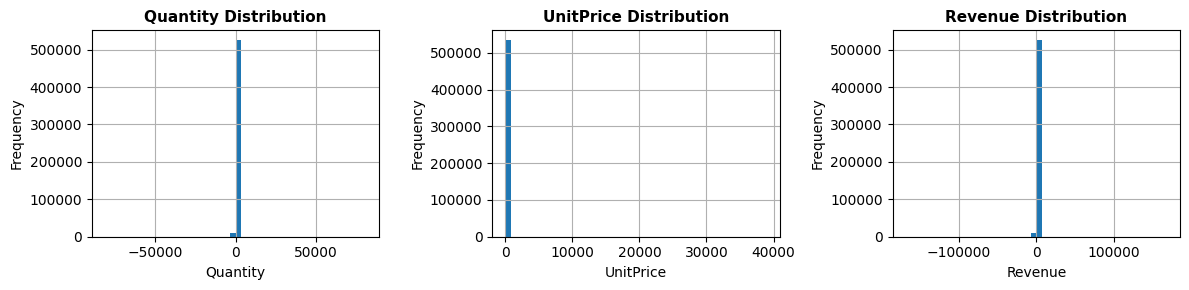

In [13]:
import matplotlib.pyplot as plt


LINE_LEVEL_COLUMNS = [
    "Quantity",
    "UnitPrice",
    "Revenue",
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(LINE_LEVEL_COLUMNS),
    figsize=(12, 3),
)

for ax, column in zip(axes, LINE_LEVEL_COLUMNS):
    sales_df[column].dropna().hist(
        bins=50,
        ax=ax,
    )

    ax.set_title(
        f"{column} Distribution",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel(column)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

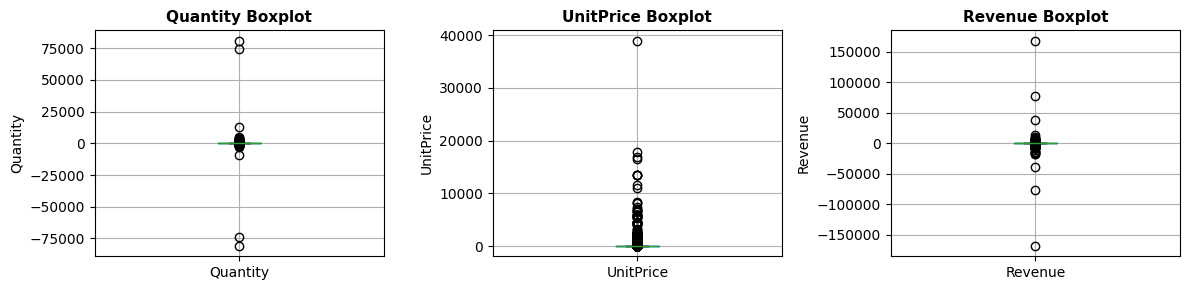

In [14]:
import matplotlib.pyplot as plt


LINE_LEVEL_COLUMNS = [
    "Quantity",
    "UnitPrice",
    "Revenue",
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=len(LINE_LEVEL_COLUMNS),
    figsize=(12, 3),
)

for ax, column in zip(axes, LINE_LEVEL_COLUMNS):
    sales_df.boxplot(
        column=column,
        ax=ax,
    )

    ax.set_title(
        f"{column} Boxplot",
        fontsize=11,
        fontweight="bold",
    )

    ax.set_ylabel(column)

plt.tight_layout()
plt.show()

### 📌 Summary Statistics & Distribution Insights
**Revenue & Transaction Characteristics**
* Revenue is highly right-skewed. The median transaction-line revenue is 9.90, compared with a mean of 18.23, while the maximum reaches 168,469.60, showing that a small number of high-value transactions pull the average upward.
* Most transaction lines generate relatively low revenue. 75% generate 17.46 or less, confirming that the majority of sales activity is concentrated in lower-value transactions.
* Negative Quantity and Revenue values reflect reversal activity. These transactions represent returns or cancellations that remain in the analytical dataset and should be evaluated separately when measuring sales performance.
  
**Customer Purchasing Patterns & Outliers**
* Purchases are primarily low-volume. The median quantity is 3 units, and 75% of transaction lines contain 10 or fewer units, despite the maximum quantity reaching 80,995 units.
* Product prices are strongly right-skewed. The median unit price is 2.10, and 75% of transaction lines are priced at 4.13 or below, while a small number of records reach 38,970.
* Distribution plots and boxplots confirm substantial extreme values across Quantity, UnitPrice, and Revenue. These values significantly influence mean-based statistics, making median and quartile measures more representative of typical transaction behavior.

# Correlation

In [15]:
# customer-level dataset
customer_df = (
    sales_df.loc[
        sales_df["CustomerID"].notna()
    ]
    .groupby("CustomerID")
    .agg(
        TotalRevenue=("Revenue", "sum"),
        TotalOrders=("InvoiceNo", "nunique"),
        TotalQuantity=("Quantity", "sum"),
        AverageUnitPrice=("UnitPrice", "mean"),
    )
    .reset_index()
)

In [16]:
# Calculate Spearman correlation
correlation_matrix = customer_df[
    [
        "TotalRevenue",
        "TotalOrders",
        "TotalQuantity",
        "AverageUnitPrice",
    ]
].corr(method="spearman")

,TotalRevenue,TotalOrders,TotalQuantity,AverageUnitPrice
TotalRevenue,1.00,0.80,0.93,0.03
TotalOrders,0.80,1.00,0.75,0.04
TotalQuantity,0.93,0.75,1.00,-0.21
AverageUnitPrice,0.03,0.04,-0.21,1.00


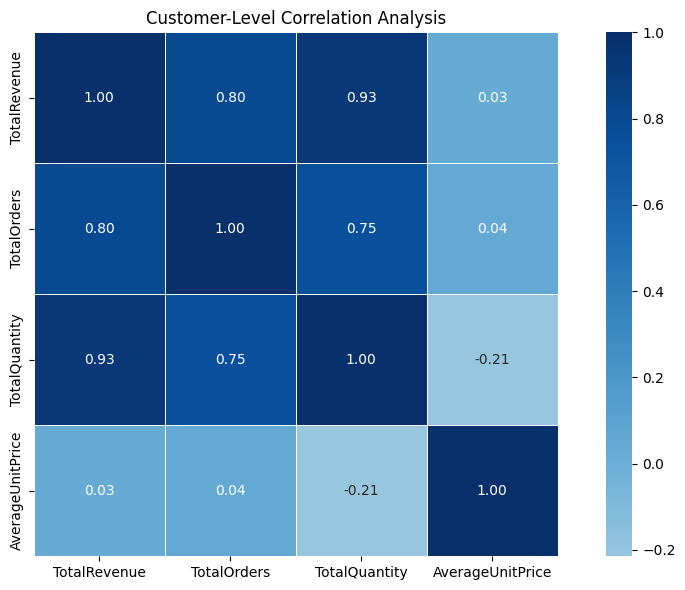

In [17]:
# Display correlation matrix
import seaborn as sns
display(correlation_matrix.round(2))


# Plot correlation heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    center=0,
    square=True,
    linewidths=0.5,
)

plt.title("Customer-Level Correlation Analysis")
plt.tight_layout()

plt.savefig(
    "../image/customer_level_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlation
* Revenue is strongly associated with purchasing volume. Total Revenue has a strong positive correlation with Total Quantity (0.93), indicating that customers purchasing more units tend to generate higher revenue.
* Repeat purchasing is also strongly associated with revenue. Total Revenue shows a strong positive correlation with Total Orders (0.80), suggesting that customers who place orders more frequently tend to contribute more revenue.
* Average unit price shows minimal relationship with customer revenue. The correlation between Average Unit Price and Total Revenue is only 0.03, indicating that higher customer revenue is not strongly associated with purchasing higher-priced products.

### Analysis

### 1. Which countries generate the highest revenue, and where should the business prioritize future expansion?

In [18]:
# Top 10 Countries by Revenue
country_revenue = (
    sales_df
    .groupby("Country", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)
country_revenue

,Country,TotalRevenue
36,United Kingdom,8189252.304
24,Netherlands,284661.540
10,EIRE,262993.380
14,Germany,221509.470
13,France,197317.110
0,Australia,137009.770
33,Switzerland,56363.050
31,Spain,54756.030
3,Belgium,40910.960
32,Sweden,36585.410


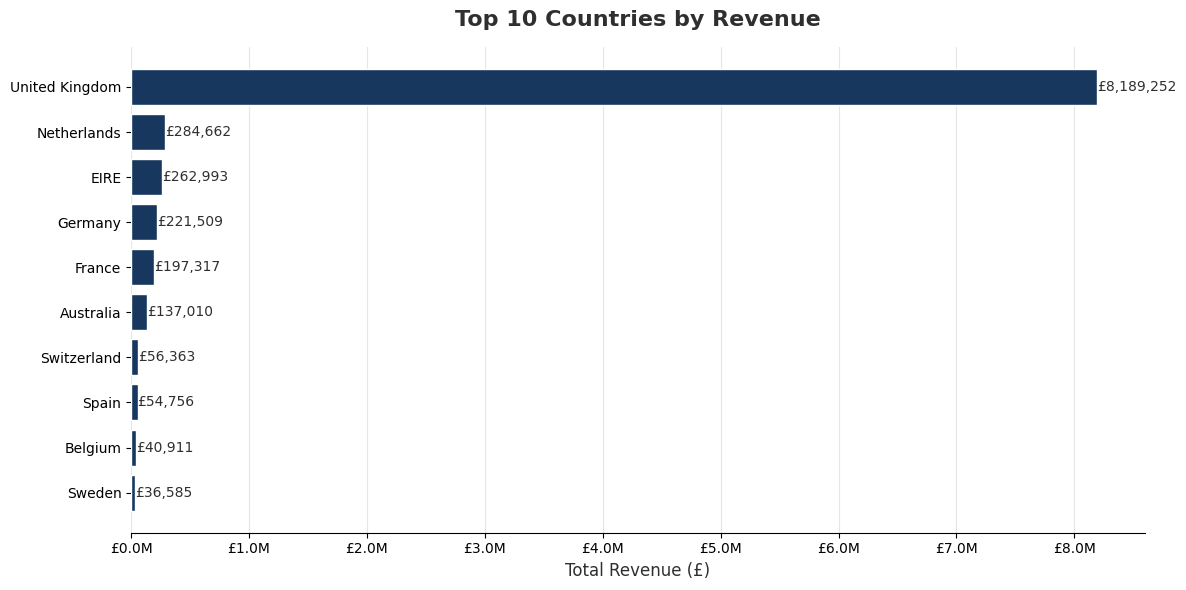

In [19]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


# Chart Configuration
PRIMARY_COLOR = "#17375E"
BACKGROUND = "#FFFFFF"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal Bar Chart
bars = ax.barh(
    country_revenue["Country"],
    country_revenue["TotalRevenue"],
    color=PRIMARY_COLOR,
    edgecolor="white"
)

# Highest Revenue at Top
ax.invert_yaxis()

# Revenue Labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"£{width:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Axis Formatting
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"£{x/1_000_000:.1f}M"))

ax.set_title(
    "Top 10 Countries by Revenue",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Total Revenue (£)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/top_10_countries_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [20]:
# Top 10 International Markets by Revenue (Excluding United Kingdom)

international_revenue = (
    sales_df.loc[sales_df["Country"] != "United Kingdom"]
    .groupby("Country", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

international_revenue

,Country,TotalRevenue
24,Netherlands,284661.54
10,EIRE,262993.38
14,Germany,221509.47
13,France,197317.11
0,Australia,137009.77
33,Switzerland,56363.05
31,Spain,54756.03
3,Belgium,40910.96
32,Sweden,36585.41
20,Japan,35340.62


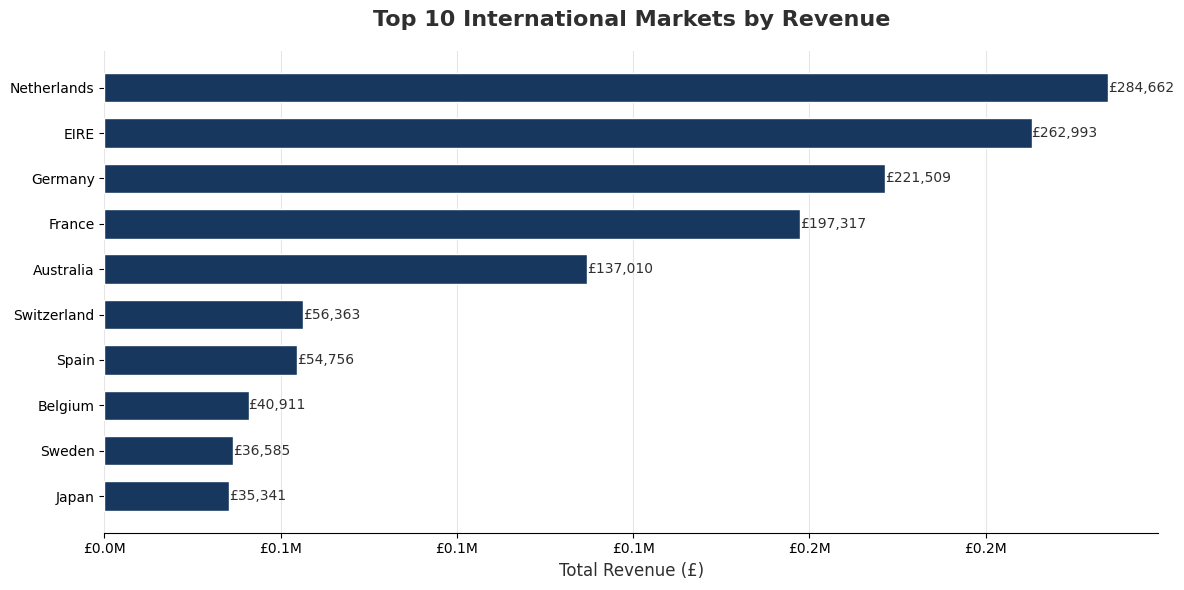

In [21]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------
# Executive Theme
# ---------------------------------
PRIMARY_COLOR = "#17375E"
BACKGROUND = "#FFFFFF"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"

fig, ax = plt.subplots(figsize=(12, 6))

# Horizontal Bars
bars = ax.barh(
    international_revenue["Country"],
    international_revenue["TotalRevenue"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.65
)

# Highest Revenue at Top
ax.invert_yaxis()

# Revenue Labels
for bar in bars:
    revenue = bar.get_width()
    ax.text(
        revenue,
        bar.get_y() + bar.get_height() / 2,
        f"£{revenue:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Format X-axis
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# Titles
ax.set_title(
    "Top 10 International Markets by Revenue",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=18
)

ax.set_xlabel(
    "Total Revenue (£)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/top_10_international_markets_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
# Revenue Contribution by Country

country_pareto = (
    sales_df
    .groupby("Country", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

# Revenue Contribution
country_pareto["RevenueContribution"] = (
    country_pareto["TotalRevenue"]
    / country_pareto["TotalRevenue"].sum()
    * 100
)

# Cumulative Contribution
country_pareto["CumulativeContribution"] = (
    country_pareto["RevenueContribution"].cumsum()
)

country_pareto.head()

,Country,TotalRevenue,RevenueContribution,CumulativeContribution
36,United Kingdom,8189252.304,84.008434,84.008434
24,Netherlands,284661.540,2.920165,86.928600
10,EIRE,262993.380,2.697885,89.626485
14,Germany,221509.470,2.272328,91.898812
13,France,197317.110,2.024153,93.922966


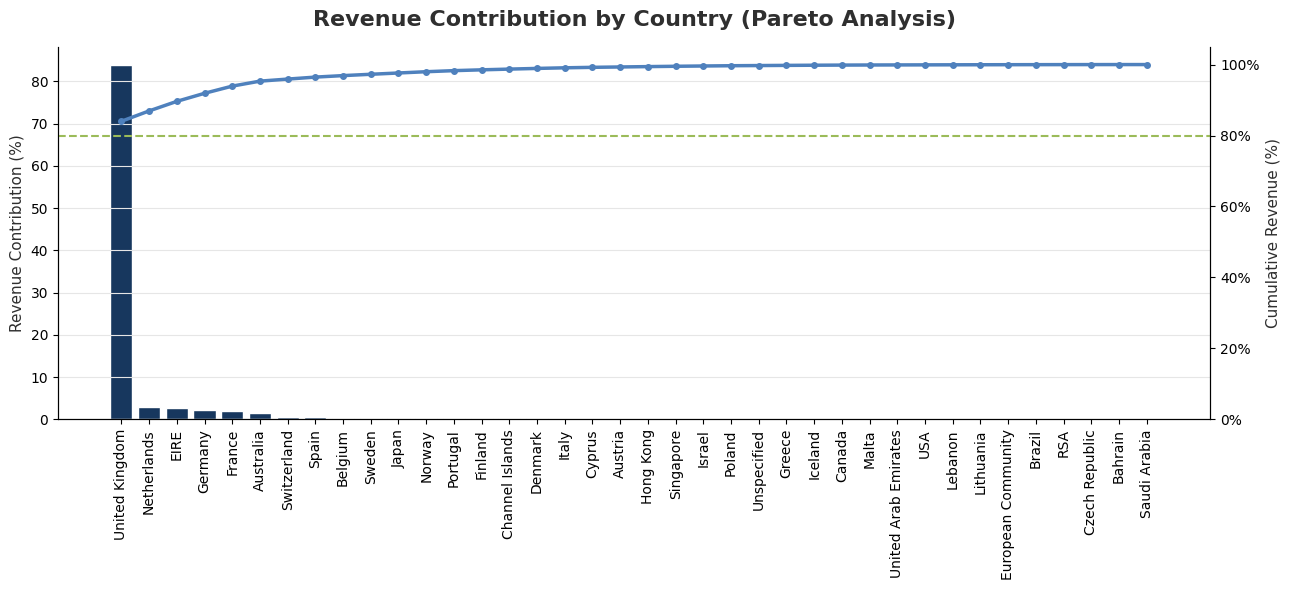

In [23]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PRIMARY_COLOR = "#17375E"
ACCENT_COLOR = "#4F81BD"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax1 = plt.subplots(figsize=(13,6))

# Revenue Bars
ax1.bar(
    country_pareto["Country"],
    country_pareto["RevenueContribution"],
    color=PRIMARY_COLOR,
    edgecolor="white"
)

ax1.set_ylabel(
    "Revenue Contribution (%)",
    fontsize=11,
    color=TEXT_COLOR
)

ax1.tick_params(axis="x", rotation=90)

ax1.grid(axis="y", color=GRID_COLOR)

# Secondary Axis
ax2 = ax1.twinx()

ax2.plot(
    country_pareto["Country"],
    country_pareto["CumulativeContribution"],
    color=ACCENT_COLOR,
    linewidth=2.5,
    marker="o",
    markersize=4
)

# 80% Reference Line
ax2.axhline(
    80,
    color="#9BBB59",
    linestyle="--",
    linewidth=1.5
)

ax2.set_ylim(0,105)
ax2.yaxis.set_major_formatter(PercentFormatter())

ax2.set_ylabel(
    "Cumulative Revenue (%)",
    fontsize=11,
    color=TEXT_COLOR
)

ax1.set_title(
    "Revenue Contribution by Country (Pareto Analysis)",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

for spine in ["top"]:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

fig.patch.set_facecolor(BACKGROUND)
ax1.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/revenue_contribution_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Market Concentration**
* The United Kingdom generated £8.19M in revenue, contributing approximately 84.0% of total revenue, indicating a high concentration of revenue within a single market.
  
**International Growth Opportunities**
* Among international markets, the Netherlands (£284.7K), EIRE (£263.0K), Germany (£221.5K), and France (£197.3K) generated the highest revenue, making them the strongest current overseas markets.
  
**Strategic Recommendation**
* The Pareto analysis shows that the United Kingdom alone contributes more than the 80% revenue concentration threshold, highlighting a significant dependence on one market. The business should evaluate high-performing international markets for targeted expansion to reduce this concentration risk.

### 2. What are the monthly and seasonal revenue trends, and when does the business achieve peak sales performance?

In [24]:
# Monthly Revenue Trend

monthly_revenue = (
    sales_df
    .groupby("MonthStart", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("MonthStart")
)

monthly_revenue.head()

,MonthStart,TotalRevenue
0,2010-12-01,746723.610
1,2011-01-01,558448.560
2,2011-02-01,497026.410
3,2011-03-01,682013.980
4,2011-04-01,492367.841


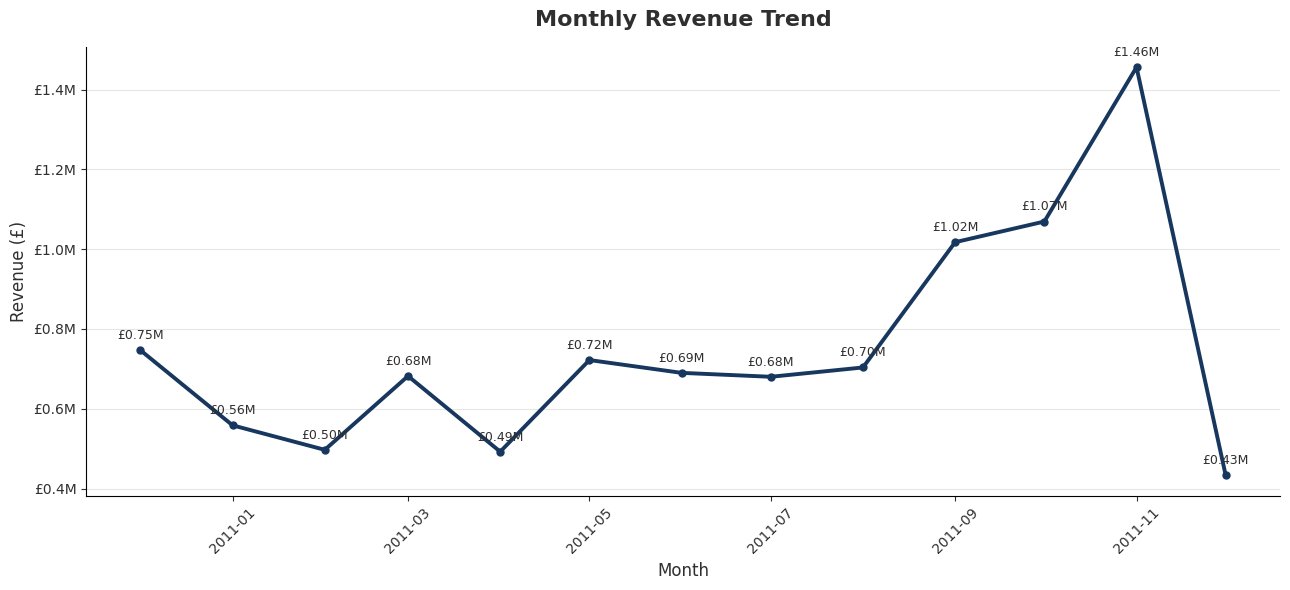

In [25]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------
# Executive Theme
# ---------------------------------------
PRIMARY_COLOR = "#17375E"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax = plt.subplots(figsize=(13, 6))

# Revenue Trend
ax.plot(
    monthly_revenue["MonthStart"],
    monthly_revenue["TotalRevenue"],
    color=PRIMARY_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=5
)

# Revenue Labels
for x, y in zip(monthly_revenue["MonthStart"], monthly_revenue["TotalRevenue"]):
    ax.annotate(
        f"£{y/1_000_000:.2f}M",
        (x, y),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        fontsize=9,
        color=TEXT_COLOR
    )

# Title
ax.set_title(
    "Monthly Revenue Trend",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

# Axis Labels
ax.set_xlabel(
    "Month",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel(
    "Revenue (£)",
    fontsize=12,
    color=TEXT_COLOR
)

# Format Y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# Grid
ax.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8
)

# Remove Chart Borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick Styling
ax.tick_params(axis="x", labelrotation=45)
ax.tick_params(colors=TEXT_COLOR)

# Background
fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/monthly_revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
# Month Order
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

monthly_seasonality = (
    sales_df
    .groupby("MonthName", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
)

monthly_seasonality["MonthName"] = pd.Categorical(
    monthly_seasonality["MonthName"],
    categories=month_order,
    ordered=True
)

monthly_seasonality = (
    monthly_seasonality
    .sort_values("MonthName")
)

monthly_seasonality

,MonthName,TotalRevenue
4,January,558448.560
3,February,497026.410
7,March,682013.980
0,April,492367.841
8,May,722094.100
6,June,689977.230
5,July,680156.991
1,August,703510.580
11,September,1017596.682
10,October,1069368.230


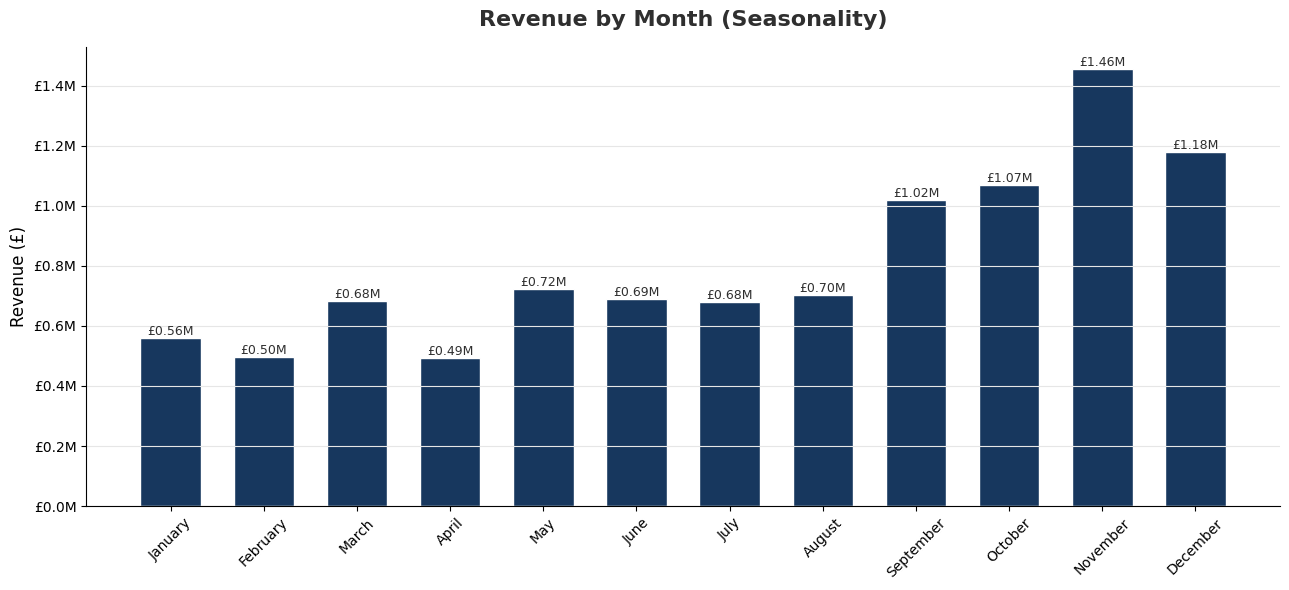

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PRIMARY_COLOR = "#17375E"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax = plt.subplots(figsize=(13,6))

bars = ax.bar(
    monthly_seasonality["MonthName"],
    monthly_seasonality["TotalRevenue"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    width=0.65
)

# Revenue Labels
for bar in bars:
    revenue = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width()/2,
        revenue,
        f"£{revenue/1_000_000:.2f}M",
        ha="center",
        va="bottom",
        fontsize=9,
        color=TEXT_COLOR
    )

ax.set_title(
    "Revenue by Month (Seasonality)",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel("")
ax.set_ylabel("Revenue (£)", fontsize=12)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

ax.grid(axis="y", color=GRID_COLOR)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=45)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/revenue_by_month(seasonality).png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Revenue Trend**
* Monthly revenue remained relatively stable between £0.49M and £0.72M from January to August, before increasing sharply from £1.02M in September and remaining above £1.0M through December.
  
**Seasonal Performance**
* November recorded the highest monthly revenue at £1.46M, followed by December at £1.18M and October at £1.07M, confirming a strong late-year revenue peak.
  
**Strategic Recommendation**
* Inventory, marketing, and operational capacity should be increased before the late-year demand period, particularly ahead of September through November, to prepare for the strongest revenue-generating months.

### 3. Which products generate the highest revenue and sales volume, and how concentrated is revenue among the top-selling products?

In [28]:
# Top 10 Products by Revenue

top_products_revenue = (
    sales_df
    .groupby("Description", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
    .head(10)
)

# Shorten long product names for better readability
top_products_revenue["Product"] = (
    top_products_revenue["Description"]
    .str.slice(0, 35)
    .str.rstrip()
)

top_products_revenue.head()

,Description,TotalRevenue,Product
1077,DOTCOM POSTAGE,206245.48,DOTCOM POSTAGE
2875,REGENCY CAKESTAND 3 TIER,164459.49,REGENCY CAKESTAND 3 TIER
3872,WHITE HANGING HEART T-LIGHT HOLDER,99612.42,WHITE HANGING HEART T-LIGHT HOLDER
2433,PARTY BUNTING,98243.88,PARTY BUNTING
1833,JUMBO BAG RED RETROSPOT,92175.79,JUMBO BAG RED RETROSPOT


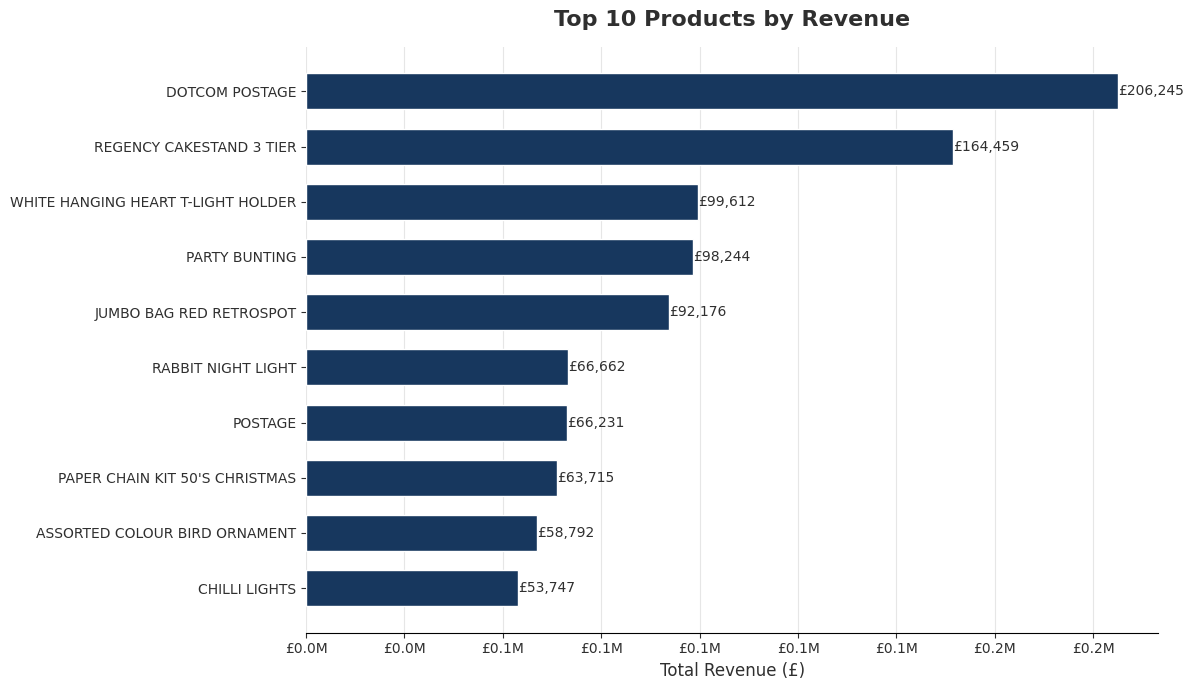

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# --------------------------------------------------
# Executive Theme
# --------------------------------------------------
PRIMARY_COLOR = "#17375E"
BACKGROUND = "#FFFFFF"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"

fig, ax = plt.subplots(figsize=(12, 7))

# Horizontal Bars
bars = ax.barh(
    top_products_revenue["Product"],
    top_products_revenue["TotalRevenue"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.65
)

# Highest Revenue on Top
ax.invert_yaxis()

# Revenue Labels
for bar in bars:
    revenue = bar.get_width()

    ax.text(
        revenue,
        bar.get_y() + bar.get_height()/2,
        f"£{revenue:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Format Axis
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# Titles
ax.set_title(
    "Top 10 Products by Revenue",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Total Revenue (£)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/top_10_product_by_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Top 10 Products by Sales Volume

top_products_quantity = (
    sales_df
    .groupby("Description", as_index=False)
    .agg(
        TotalQuantity=("Quantity", "sum")
    )
    .sort_values("TotalQuantity", ascending=False)
    .head(10)
)

# Shorten long product names
top_products_quantity["Product"] = (
    top_products_quantity["Description"]
    .apply(lambda x: x if len(x) <= 35 else x[:35] + "...")
)

top_products_quantity.head()

,Description,TotalQuantity,Product
3963,WORLD WAR 2 GLIDERS ASSTD DESIGNS,53751,WORLD WAR 2 GLIDERS ASSTD DESIGNS
1833,JUMBO BAG RED RETROSPOT,47260,JUMBO BAG RED RETROSPOT
2702,POPCORN HOLDER,36322,POPCORN HOLDER
229,ASSORTED COLOUR BIRD ORNAMENT,36282,ASSORTED COLOUR BIRD ORNAMENT
2357,PACK OF 72 RETROSPOT CAKE CASES,36016,PACK OF 72 RETROSPOT CAKE CASES


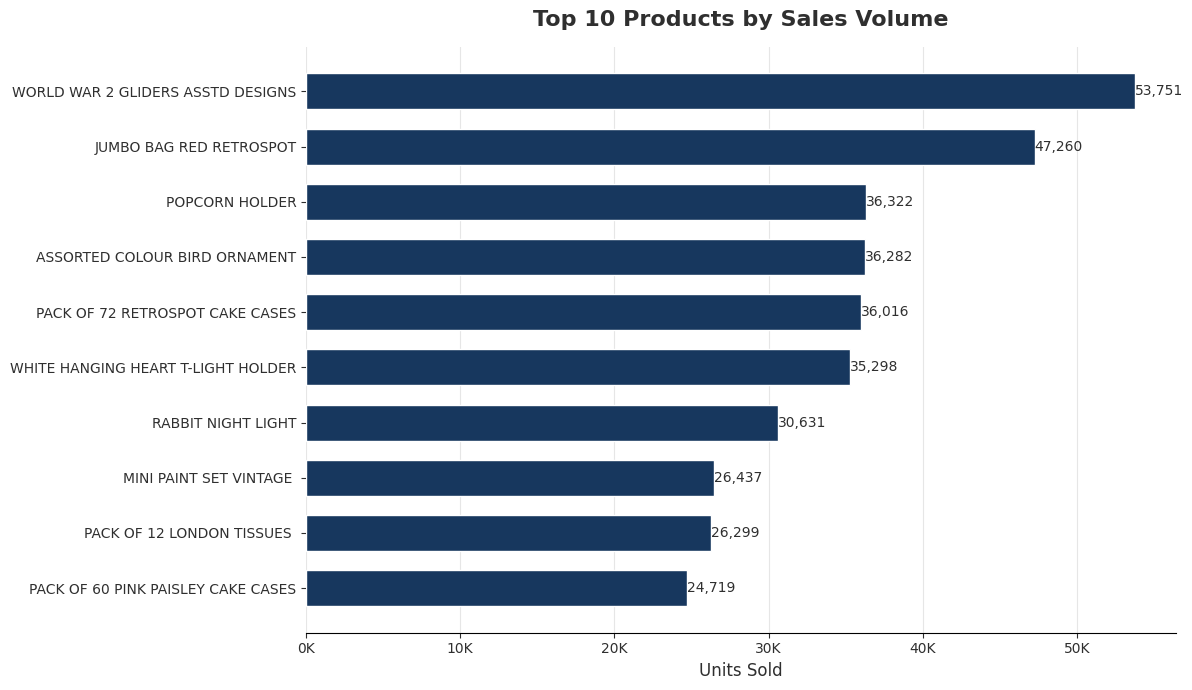

In [31]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------
# Executive Theme
# ---------------------------------------
PRIMARY_COLOR = "#17375E"
BACKGROUND = "#FFFFFF"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"

fig, ax = plt.subplots(figsize=(12, 7))

# Horizontal Bars
bars = ax.barh(
    top_products_quantity["Product"],
    top_products_quantity["TotalQuantity"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.65
)

# Highest at Top
ax.invert_yaxis()

# Quantity Labels
for bar in bars:
    quantity = bar.get_width()

    ax.text(
        quantity,
        bar.get_y() + bar.get_height() / 2,
        f"{quantity:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Format X-axis
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x/1000:.0f}K")
)

# Titles
ax.set_title(
    "Top 10 Products by Sales Volume",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Units Sold",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/top_10_product_by_sales_valume.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [12]:
# Product Revenue Pareto Analysis

product_pareto = (
    sales_df
    .groupby("Description", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

# Keep Top 20 Products for readability
product_pareto = product_pareto.head(20)

# Shorten Product Names
product_pareto["Product"] = (
    product_pareto["Description"]
    .apply(lambda x: x if len(x) <= 35 else x[:35] + "...")
)

# Revenue Contribution %
product_pareto["RevenueContribution"] = (
    product_pareto["TotalRevenue"]
    / product_pareto["TotalRevenue"].sum()
    * 100
)

# Cumulative %
product_pareto["CumulativeRevenue"] = (
    product_pareto["RevenueContribution"].cumsum()
)

product_pareto.head()

,Description,TotalRevenue,Product,RevenueContribution,CumulativeRevenue
1077,DOTCOM POSTAGE,206245.48,DOTCOM POSTAGE,15.298409,15.298409
2875,REGENCY CAKESTAND 3 TIER,164459.49,REGENCY CAKESTAND 3 TIER,12.198903,27.497312
3872,WHITE HANGING HEART T-LIGHT HOLDER,99612.42,WHITE HANGING HEART T-LIGHT HOLDER,7.388824,34.886135
2433,PARTY BUNTING,98243.88,PARTY BUNTING,7.287311,42.173447
1833,JUMBO BAG RED RETROSPOT,92175.79,JUMBO BAG RED RETROSPOT,6.837206,49.010653


In [34]:
# Product Revenue Pareto Analysis

product_pareto = (
    sales_df
    .groupby("Description", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

# Calculate contribution using total revenue across all products
total_revenue = product_pareto["TotalRevenue"].sum()

product_pareto["RevenueContribution"] = (
    product_pareto["TotalRevenue"]
    / total_revenue
    * 100
)

# Calculate cumulative contribution across all products
product_pareto["CumulativeRevenue"] = (
    product_pareto["RevenueContribution"]
    .cumsum()
)

# Keep top 20 products for chart readability
top_20_products = product_pareto.head(20).copy()

# Shorten product names for visualization
top_20_products["Product"] = (
    top_20_products["Description"]
    .apply(lambda x: x if len(x) <= 35 else x[:35] + "...")
)
product_pareto

,Description,TotalRevenue,RevenueContribution,CumulativeRevenue
1077,DOTCOM POSTAGE,206245.480,2.115744,2.115744
2875,REGENCY CAKESTAND 3 TIER,164459.490,1.687087,3.802831
3872,WHITE HANGING HEART T-LIGHT HOLDER,99612.420,1.021862,4.824693
2433,PARTY BUNTING,98243.880,1.007823,5.832516
1833,JUMBO BAG RED RETROSPOT,92175.790,0.945574,6.778090
...,...,...,...,...
1101,Discount,-5696.220,-0.058434,103.135588
598,Bank Charges,-7175.639,-0.073610,103.061977
915,CRUK Commission,-7933.430,-0.081384,102.980593
2211,Manual,-69031.640,-0.708153,102.272441


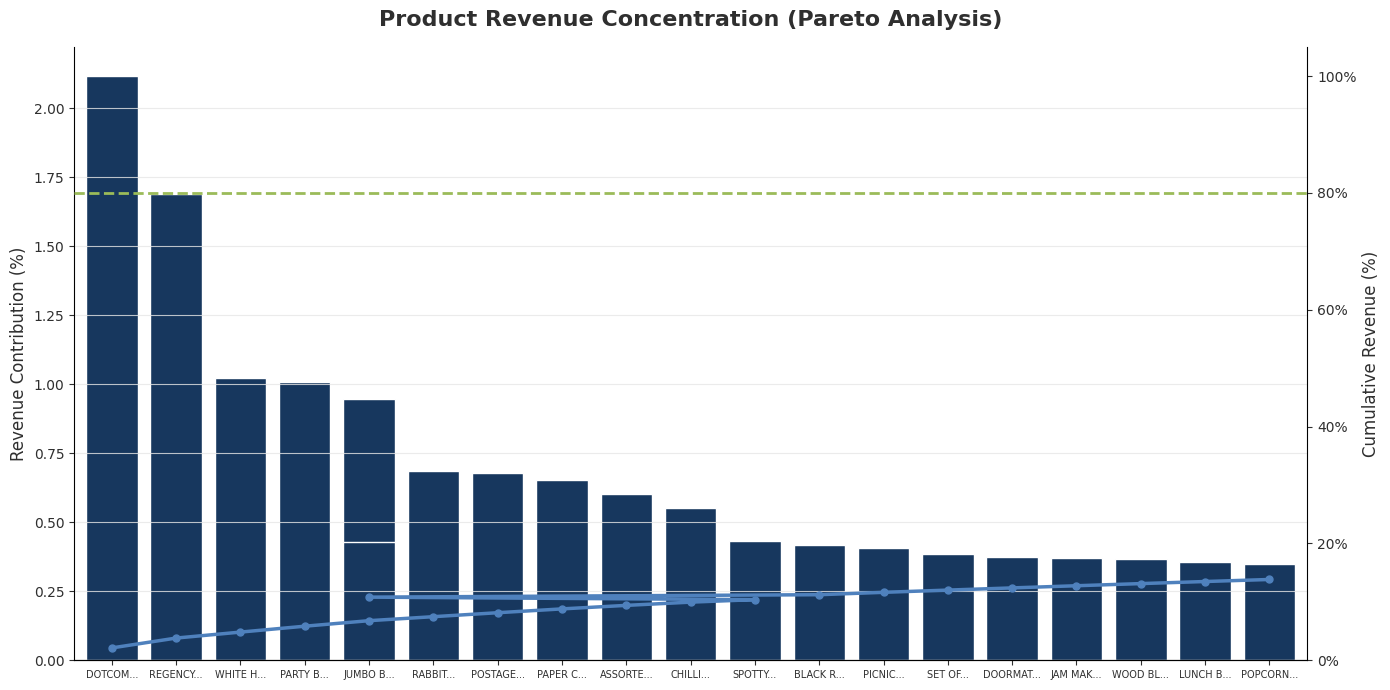

In [72]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

PRIMARY_COLOR = "#17375E"
ACCENT_COLOR = "#4F81BD"
SUCCESS_COLOR = "#9BBB59"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

# Use the Top 20 products prepared for visualization
plot_df = top_20_products.copy()

# Short display names for the x-axis
plot_df["DisplayProduct"] = (
    plot_df["Product"]
    .str.slice(0, 7)
    .str.rstrip()
    + "..."
)

fig, ax1 = plt.subplots(figsize=(14, 7))

# Revenue Contribution Bars
ax1.bar(
    plot_df["DisplayProduct"],
    plot_df["RevenueContribution"],
    color=PRIMARY_COLOR,
    edgecolor="white"
)

ax1.set_ylabel(
    "Revenue Contribution (%)",
    fontsize=12,
    color=TEXT_COLOR
)

ax1.grid(
    axis="y",
    color=GRID_COLOR,
    linewidth=0.8,
    alpha=0.8
)

ax2 = ax1.twinx()

ax2.plot(
    plot_df["DisplayProduct"],
    plot_df["CumulativeRevenue"],
    color=ACCENT_COLOR,
    linewidth=2.5,
    marker="o",
    markersize=5
)

ax2.axhline(
    y=80,
    color=SUCCESS_COLOR,
    linestyle="--",
    linewidth=2,
    label="80% Threshold"
)

ax2.set_ylim(0, 105)
ax2.yaxis.set_major_formatter(PercentFormatter())

ax2.set_ylabel(
    "Cumulative Revenue (%)",
    fontsize=12,
    color=TEXT_COLOR
)

ax1.set_title(
    "Product Revenue Concentration (Pareto Analysis)",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax1.tick_params(
    axis="x",
    labelsize=7,
    colors=TEXT_COLOR
)

ax1.tick_params(axis="y", colors=TEXT_COLOR)
ax2.tick_params(axis="y", colors=TEXT_COLOR)

plt.xticks(rotation=30, ha="right")

ax1.margins(x=0.01)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.spines["top"].set_visible(False)
ax2.spines["left"].set_visible(False)

fig.patch.set_facecolor(BACKGROUND)
ax1.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/product_revenue_concentration.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Product Performance**
* WORLD WAR 2 GLIDERS ASSTD DESIGNS recorded the highest sales volume at 53,751 units, while DOTCOM POSTAGE generated the highest revenue at £206.2K, showing that the products driving unit sales are not necessarily the same as those generating the most revenue.

**Revenue Concentration**
* The top 10 products contribute approximately 9.9% of total revenue, indicating that revenue is distributed across a broad product portfolio rather than being heavily dependent on a small number of individual products.

**Strategic Recommendation**

Maintain strong availability of high-revenue and high-volume products, but avoid concentrating inventory or promotional investment on only a small product group, as revenue is generated across a relatively broad range of products.

### 4.How do order cancellations impact total revenue, and what opportunities exist to reduce revenue loss?

In [38]:
# Revenue by Order Type

order_type_revenue = (
    sales_df
    .groupby("OrderType", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
)

# Calculate cancellation impact
gross_sales_revenue = (
    order_type_revenue.loc[
        order_type_revenue["OrderType"] == "Sale",
        "TotalRevenue"
    ]
    .iloc[0]
)

cancelled_revenue = (
    order_type_revenue.loc[
        order_type_revenue["OrderType"] == "Cancellation",
        "TotalRevenue"
    ]
    .abs()
    .iloc[0]
)

cancellation_rate = (
    cancelled_revenue
    / gross_sales_revenue
    * 100
)

order_type_revenue

,OrderType,TotalRevenue
0,Cancellation,-8.939797e+05
1,Sale,1.064211e+07


In [40]:
gross_sales_revenue

np.float64(10642110.804)

In [41]:
cancellation_rate

np.float64(8.400398628287013)

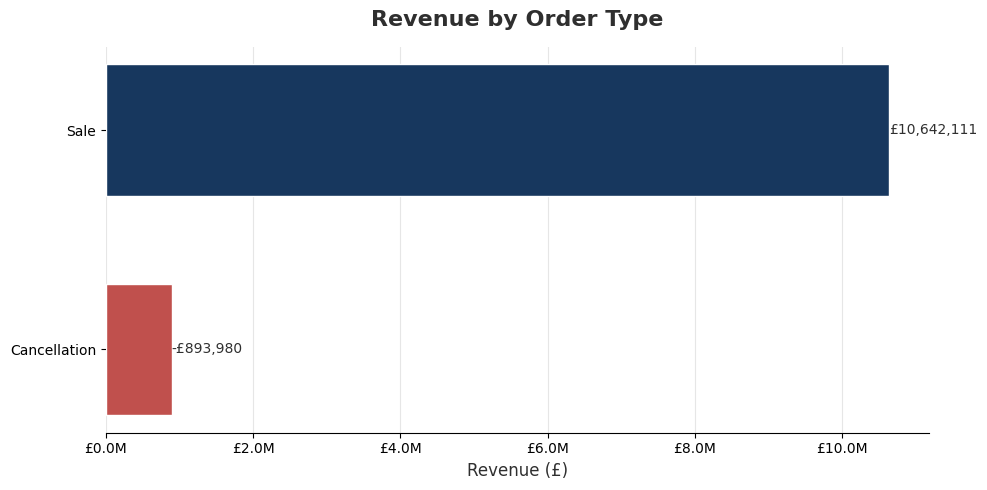

In [42]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------
# Executive Theme
# ---------------------------------------
PRIMARY_COLOR = "#17375E"
NEGATIVE_COLOR = "#C0504D"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

# Explicit color mapping by order type
ORDER_TYPE_COLORS = {
    "Sale": PRIMARY_COLOR,
    "Cancellation": NEGATIVE_COLOR,
}

bar_colors = (
    order_type_revenue["OrderType"]
    .map(ORDER_TYPE_COLORS)
)

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    order_type_revenue["OrderType"],
    order_type_revenue["TotalRevenue"].abs(),
    color=bar_colors,
    edgecolor="white",
    height=0.6
)

# Revenue Labels
for bar, (_, row) in zip(
    bars,
    order_type_revenue.iterrows(),
):
    value = row["TotalRevenue"]

    label = (
        f"£{value:,.0f}"
        if value >= 0
        else f"-£{abs(value):,.0f}"
    )

    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Format Axis
ax.xaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"£{x / 1_000_000:.1f}M"
    )
)

ax.set_title(
    "Revenue by Order Type",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Revenue (£)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8,
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/revenue_by_order_type.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [43]:
# Monthly Cancelled Revenue trend

monthly_cancellations = (
    sales_df.loc[sales_df["OrderType"] == "Cancellation"]
    .groupby("MonthStart", as_index=False)
    .agg(
        CancelledRevenue=("Revenue", "sum")
    )
    .sort_values("MonthStart")
)

monthly_cancellations["CancelledRevenue"] = (
    monthly_cancellations["CancelledRevenue"].abs()
)

monthly_cancellations.head()

,MonthStart,CancelledRevenue
0,2010-12-01,74729.12
1,2011-01-01,131363.05
2,2011-02-01,25519.15
3,2011-03-01,34201.28
4,2011-04-01,44600.65


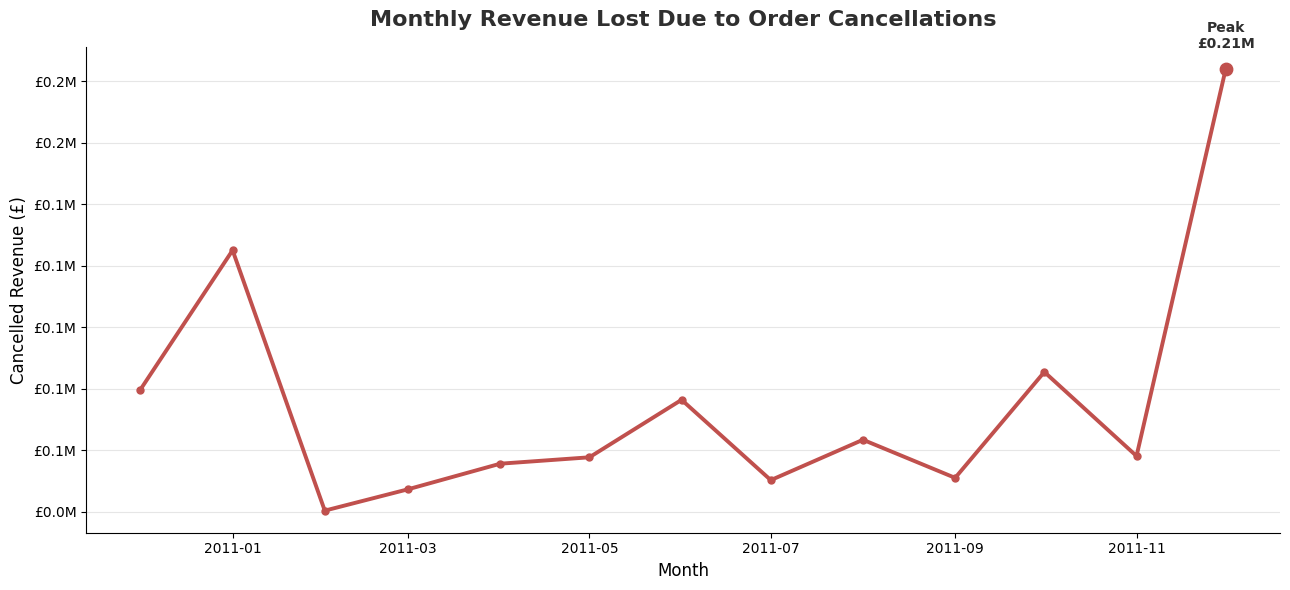

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------
# Executive Theme
# ---------------------------------------
NEGATIVE_COLOR = "#C0504D"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax = plt.subplots(figsize=(13, 6))

# Cancellation Trend
ax.plot(
    monthly_cancellations["MonthStart"],
    monthly_cancellations["CancelledRevenue"],
    color=NEGATIVE_COLOR,
    linewidth=2.8,
    marker="o",
    markersize=5
)

# Highlight Peak Cancellation Month
peak = monthly_cancellations.loc[
    monthly_cancellations["CancelledRevenue"].idxmax()
]

ax.scatter(
    peak["MonthStart"],
    peak["CancelledRevenue"],
    color=NEGATIVE_COLOR,
    s=80,
    zorder=3
)

ax.annotate(
    f"Peak\n£{peak['CancelledRevenue']/1_000_000:.2f}M",
    (peak["MonthStart"], peak["CancelledRevenue"]),
    xytext=(0, 15),
    textcoords="offset points",
    ha="center",
    fontsize=10,
    fontweight="bold",
    color=TEXT_COLOR
)

# Formatting
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

ax.set_title(
    "Monthly Revenue Lost Due to Order Cancellations",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel("Month", fontsize=12)
ax.set_ylabel("Cancelled Revenue (£)", fontsize=12)

ax.grid(axis="y", color=GRID_COLOR)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/monthly_revenue_los.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Cancellation Impact**
* Order cancellations resulted in approximately £894.0K in lost revenue, equivalent to 8.4% of gross sales revenue, making cancellations a significant source of revenue leakage.

**Cancellation Trend**
* Cancellation-related revenue loss increased sharply during the year-end period, peaking at approximately £0.21M in December, indicating greater cancellation risk during the highest-demand sales period.
  
**Strategic Recommendation**
* Prioritize root-cause analysis of cancellations during the year-end peak period, focusing on factors such as stock availability, order fulfillment, and customer order behavior, to reduce revenue leakage without disrupting high-demand sales.

### 5.Which customer segments generate the highest revenue and purchase most frequently?

In [45]:
# Revenue by Customer Segment

customer_segment_revenue = (
    sales_df
    .groupby("CustomerType", as_index=False)
    .agg(
        TotalRevenue=("Revenue", "sum")
    )
    .sort_values("TotalRevenue", ascending=False)
)

customer_segment_revenue

,CustomerType,TotalRevenue
1,Registered Customer,8278519.424
0,Guest Customer,1469611.650


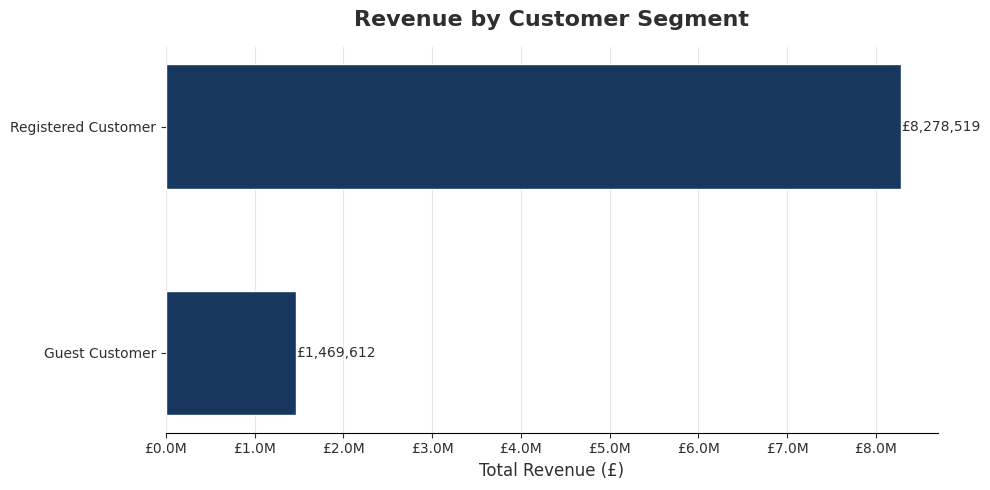

In [46]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ---------------------------------------
# Executive Theme
# ---------------------------------------
PRIMARY_COLOR = "#17375E"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax = plt.subplots(figsize=(10, 5))

# Horizontal Bars
bars = ax.barh(
    customer_segment_revenue["CustomerType"],
    customer_segment_revenue["TotalRevenue"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.55
)

# Highest Revenue at Top
ax.invert_yaxis()

# Revenue Labels
for bar in bars:
    revenue = bar.get_width()

    ax.text(
        revenue,
        bar.get_y() + bar.get_height()/2,
        f"£{revenue:,.0f}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Format Axis
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"£{x/1_000_000:.1f}M")
)

# Titles
ax.set_title(
    "Revenue by Customer Segment",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Total Revenue (£)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/Revenue_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [48]:
# Revenue Contribution by Customer Segment

customer_revenue_pct = (
    customer_segment_revenue
    .assign(
        RevenueContribution=lambda df:
        (df["TotalRevenue"] / df["TotalRevenue"].sum()) * 100
    )
    .sort_values("RevenueContribution", ascending=False)
)
customer_revenue_pct

,CustomerType,TotalRevenue,RevenueContribution
1,Registered Customer,8278519.424,84.92417
0,Guest Customer,1469611.650,15.07583


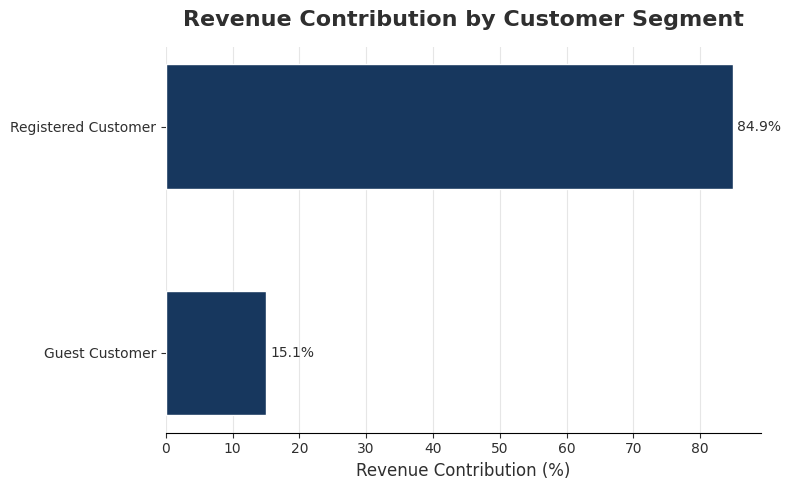

In [39]:
# ---------------------------------------
# Executive Theme
# ---------------------------------------
PRIMARY_COLOR = "#17375E"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.barh(
    customer_revenue_pct["CustomerType"],
    customer_revenue_pct["RevenueContribution"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.55
)

ax.invert_yaxis()

# Percentage Labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Title
ax.set_title(
    "Revenue Contribution by Customer Segment",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Revenue Contribution (%)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/Revenue_contribution_by_customer_segment.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [53]:
# customer purchase frequency 
customer_frequency = (
    sales_df.loc[
        sales_df["CustomerID"].notna(),
        [
            "CustomerID",
            "CustomerType",
            "PurchaseFrequency",
        ],
    ]
    .drop_duplicates("CustomerID")
)
customer_frequency

,CustomerID,CustomerType,PurchaseFrequency
0,17850,Registered Customer,34
9,13047,Registered Customer,10
26,12583,Registered Customer,15
46,13748,Registered Customer,5
65,15100,Registered Customer,3
...,...,...,...
529696,13436,Registered Customer,1
529977,15520,Registered Customer,1
530777,13298,Registered Customer,1
531511,14569,Registered Customer,1


In [54]:
customer_segment_frequency = (
    customer_frequency
    .groupby("CustomerType", as_index=False)
    .agg(
        AveragePurchaseFrequency=(
            "PurchaseFrequency",
            "mean",
        )
    )
    .sort_values(
        "AveragePurchaseFrequency",
        ascending=False,
    )
)
customer_segment_frequency

,CustomerType,AveragePurchaseFrequency
0,Registered Customer,4.271722


**Customer Revenue Distribution**
* Registered Customers generated £8.28M (84.9%) of total revenue, compared with £1.47M (15.1%) from Guest Customers, making the business highly dependent on its registered customer base.

**Customer Value**
* Registered Customers contributed 5.6× more revenue than Guest Customers and placed an average of 4.3 purchases per customer, demonstrating the importance of repeat customers to overall revenue performance.
  
**Strategic Recommendation**
* Prioritize customer acquisition and retention initiatives that convert Guest Customers into Registered Customers, while maintaining engagement with existing registered customers to protect the repeat purchasing behavior that drives nearly 85% of total revenue.

### 6. Which products are most popular among customers, and how do purchasing patterns vary across different countries?

In [56]:
# Top 10 Products by Customer Reach

top_products_customers = (
    sales_df
    .loc[sales_df["CustomerID"].notna()]
    .groupby("Description", as_index=False)
    .agg(
        UniqueCustomers=("CustomerID", "nunique")
    )
    .sort_values("UniqueCustomers", ascending=False)
    .head(10)
)

# Shorten long product names
top_products_customers["Product"] = (
    top_products_customers["Description"]
    .apply(lambda x: x if len(x) <= 35 else x[:35] + "...")
)

top_products_customers.head()

,Description,UniqueCustomers,Product
2780,REGENCY CAKESTAND 3 TIER,887,REGENCY CAKESTAND 3 TIER
3716,WHITE HANGING HEART T-LIGHT HOLDER,858,WHITE HANGING HEART T-LIGHT HOLDER
2355,PARTY BUNTING,708,PARTY BUNTING
217,ASSORTED COLOUR BIRD ORNAMENT,679,ASSORTED COLOUR BIRD ORNAMENT
3014,SET OF 3 CAKE TINS PANTRY DESIGN,640,SET OF 3 CAKE TINS PANTRY DESIGN


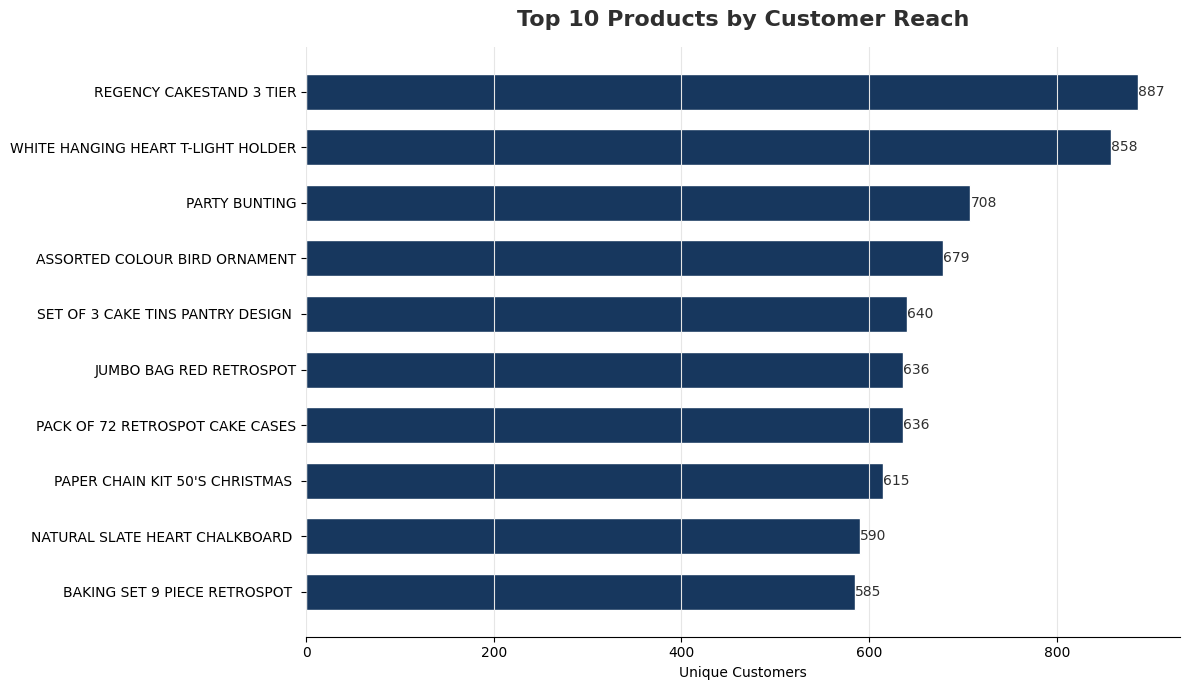

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,7))

bars = ax.barh(
    top_products_customers["Product"],
    top_products_customers["UniqueCustomers"],
    color="#17375E",
    edgecolor="white",
    height=0.65
)

ax.invert_yaxis()

for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y()+bar.get_height()/2,
        f"{value:,}",
        va="center",
        ha="left",
        fontsize=10,
        color="#2F2F2F"
    )

ax.set_title(
    "Top 10 Products by Customer Reach",
    fontsize=16,
    fontweight="bold",
    color="#2F2F2F",
    pad=15
)

ax.set_xlabel("Unique Customers")
ax.set_ylabel("")

ax.grid(axis="x", color="#E6E6E6")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "../image/top_10_product_by_customer_reach.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [58]:
# Top 10 Revenue-Generating Countries

top_countries = (
    sales_df
    .groupby("Country")["Revenue"]
    .sum()
    .nlargest(10)
    .index
)

In [59]:
top_products = top_products_customers["Description"].tolist()

In [60]:
# Product Popularity by Country

product_country = (
    sales_df[
        sales_df["Country"].isin(top_countries) &
        sales_df["Description"].isin(top_products)
    ]
    .groupby(["Description", "Country"])
    .agg(
        QuantitySold=("Quantity", "sum")
    )
    .reset_index()
)

heatmap_data = (
    product_country
    .pivot(
        index="Description",
        columns="Country",
        values="QuantitySold"
    )
    .fillna(0)
)

heatmap_data

Country,Australia,Belgium,EIRE,France,Germany,Netherlands,Spain,Sweden,Switzerland,United Kingdom
Description,,,,,,,,,,
ASSORTED COLOUR BIRD ORNAMENT,0.0,8.0,288.0,1204.0,224.0,320.0,417.0,0.0,59.0,33580.0
BAKING SET 9 PIECE RETROSPOT,111.0,15.0,167.0,194.0,58.0,27.0,24.0,0.0,39.0,4047.0
JUMBO BAG RED RETROSPOT,210.0,110.0,146.0,440.0,522.0,2000.0,41.0,10.0,110.0,43064.0
NATURAL SLATE HEART CHALKBOARD,144.0,12.0,120.0,6.0,6.0,0.0,6.0,0.0,0.0,8695.0
PACK OF 72 RETROSPOT CAKE CASES,360.0,480.0,1728.0,1176.0,1002.0,4128.0,264.0,984.0,432.0,24679.0
PAPER CHAIN KIT 50'S CHRISTMAS,38.0,0.0,410.0,31.0,24.0,120.0,16.0,0.0,6.0,18177.0
PARTY BUNTING,265.0,8.0,407.0,126.0,34.0,50.0,38.0,0.0,86.0,16697.0
REGENCY CAKESTAND 3 TIER,180.0,47.0,653.0,220.0,737.0,289.0,137.0,0.0,76.0,10354.0
SET OF 3 CAKE TINS PANTRY DESIGN,463.0,18.0,367.0,22.0,117.0,43.0,20.0,357.0,0.0,5564.0


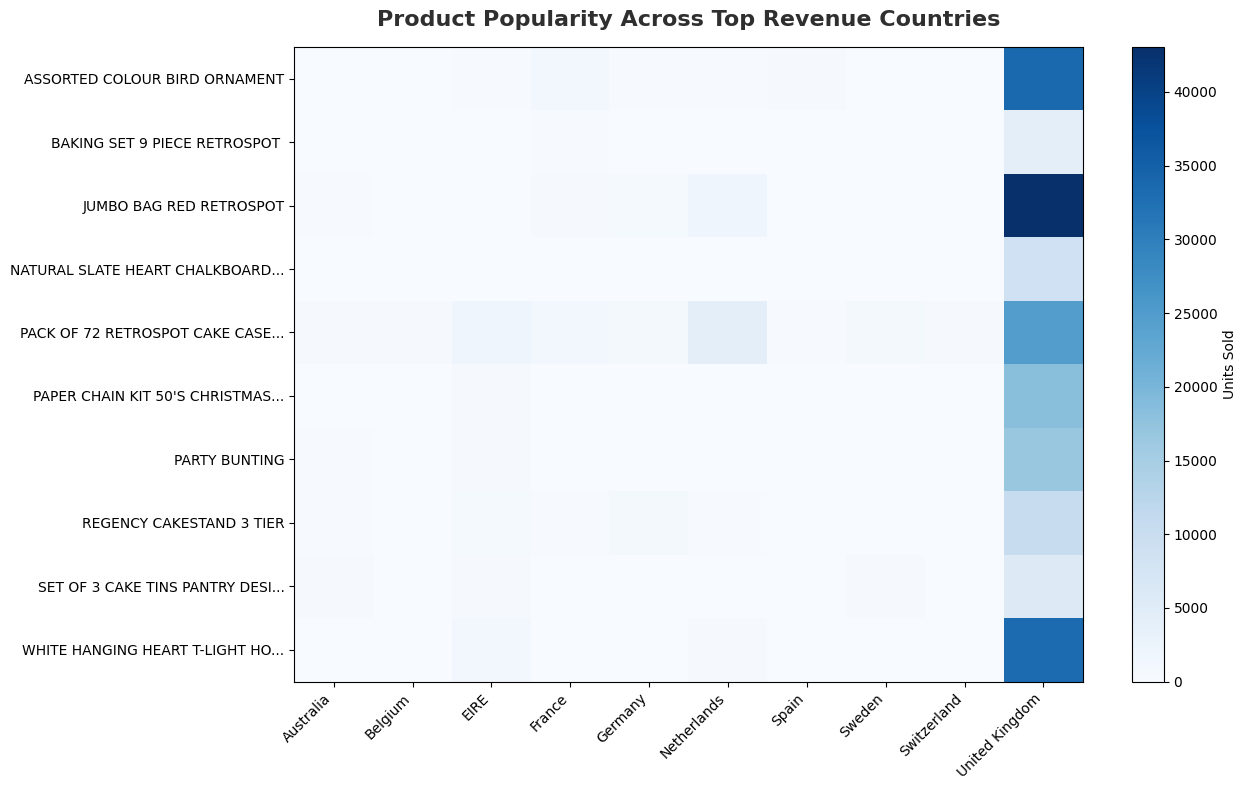

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13, 8))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="Blues"
)

# Labels
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(
    heatmap_data.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(
    [
        p if len(p) <= 30 else p[:30] + "..."
        for p in heatmap_data.index
    ]
)

# Title
ax.set_title(
    "Product Popularity Across Top Revenue Countries",
    fontsize=16,
    fontweight="bold",
    color="#2F2F2F",
    pad=15
)

# Color Scale
cbar = plt.colorbar(im)
cbar.set_label("Units Sold")

plt.tight_layout()

plt.savefig(
    "../image/product_popularity_across_top_revenue_countries.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Product Popularity**
* REGENCY CAKESTAND 3 TIER reached the largest registered customer base, purchased by 887 unique customers, followed by WHITE HANGING HEART T-LIGHT HOLDER (858) and PARTY BUNTING (708), indicating broad customer appeal.

**Country Purchasing Patterns**
* The United Kingdom records the highest sales volume across nearly all high-reach products, with products such as JUMBO BAG RED RETROSPOT and ASSORTED COLOUR BIRD ORNAMENT selling substantially more units than in international markets.

**Strategic Recommendation**
* Use high-customer-reach products as priority candidates for international expansion, particularly in stronger overseas markets such as the Netherlands, Germany, France, and EIRE, while validating local demand before increasing inventory.

### 7. Which countries have the highest customer engagement and repeat purchase rates?

In [62]:
# Repeat Customer Rate by Country

country_repeat_rate = (
    sales_df.loc[
        sales_df["CustomerID"].notna()
        & sales_df["OrderType"].eq("Sale")
    ]
    .drop_duplicates(subset=["CustomerID", "Country"])
    .assign(
        IsRepeat=lambda df: df["RepeatCustomer"].eq("Repeat Customer")
    )
    .groupby("Country", as_index=False)
    .agg(
        TotalCustomers=("CustomerID", "nunique"),
        RepeatCustomers=("IsRepeat", "sum")
    )
)

# Calculate repeat customer rate
country_repeat_rate["RepeatRate"] = (
    country_repeat_rate["RepeatCustomers"]
    / country_repeat_rate["TotalCustomers"]
    * 100
)

# Apply minimum customer threshold
MIN_CUSTOMERS = 30

country_repeat_rate = (
    country_repeat_rate
    .loc[country_repeat_rate["TotalCustomers"] >= MIN_CUSTOMERS]
    .sort_values("RepeatRate", ascending=False)
)

country_repeat_rate

,Country,TotalCustomers,RepeatCustomers,RepeatRate
14,Germany,94,68,72.340426
13,France,87,59,67.816092
30,Spain,30,20,66.666667
35,United Kingdom,3921,2570,65.544504


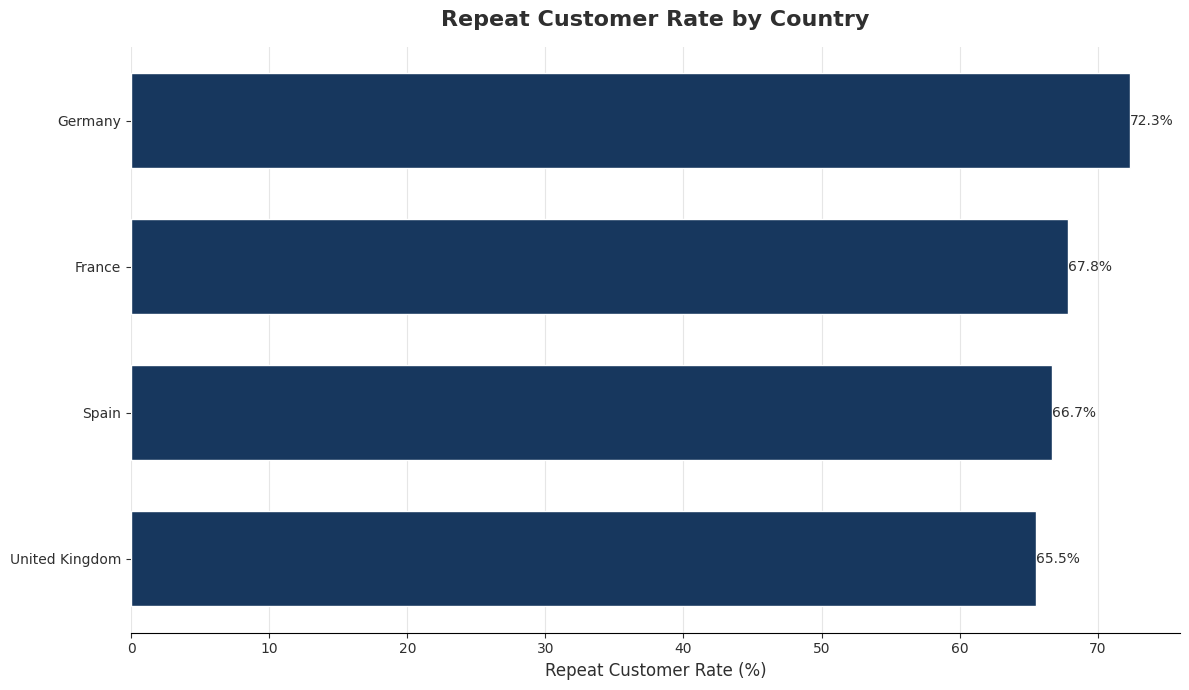

In [64]:
import matplotlib.pyplot as plt

PRIMARY_COLOR = "#17375E"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"
BACKGROUND = "#FFFFFF"

fig, ax = plt.subplots(figsize=(12, 7))

# Horizontal Bars
bars = ax.barh(
    country_repeat_rate["Country"],
    country_repeat_rate["RepeatRate"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.65
)

# Highest at Top
ax.invert_yaxis()

# Value Labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value,
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Title
ax.set_title(
    "Repeat Customer Rate by Country",
    fontsize=16,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

ax.set_xlabel(
    "Repeat Customer Rate (%)",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Styling
ax.grid(axis="x", color=GRID_COLOR, linewidth=0.8)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/repeat_customer_rate_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [65]:
# Average Purchase Frequency by Country

# Keep identifiable customers with completed Sale transactions
sales_customers = (
    sales_df.loc[
        sales_df["CustomerID"].notna()
        & sales_df["OrderType"].eq("Sale")
    ]
    .copy()
)

# Calculate unique completed purchases for each customer
customer_purchase_frequency = (
    sales_customers
    .groupby(["Country", "CustomerID"], as_index=False)
    .agg(
        PurchaseFrequency=("InvoiceNo", "nunique")
    )
)

# Aggregate to country level
country_purchase_frequency = (
    customer_purchase_frequency
    .groupby("Country", as_index=False)
    .agg(
        AveragePurchaseFrequency=("PurchaseFrequency", "mean"),
        TotalCustomers=("CustomerID", "nunique")
    )
)

# Minimum customer threshold
MIN_CUSTOMERS = 30

# Keep only countries meeting the threshold
country_purchase_frequency = (
    country_purchase_frequency
    .loc[
        country_purchase_frequency["TotalCustomers"] >= MIN_CUSTOMERS
    ]
    .sort_values(
        "AveragePurchaseFrequency",
        ascending=False
    )
)

country_purchase_frequency

,Country,AveragePurchaseFrequency,TotalCustomers
14,Germany,4.861702,94
13,France,4.471264,87
35,United Kingdom,4.245856,3921
30,Spain,3.000000,30


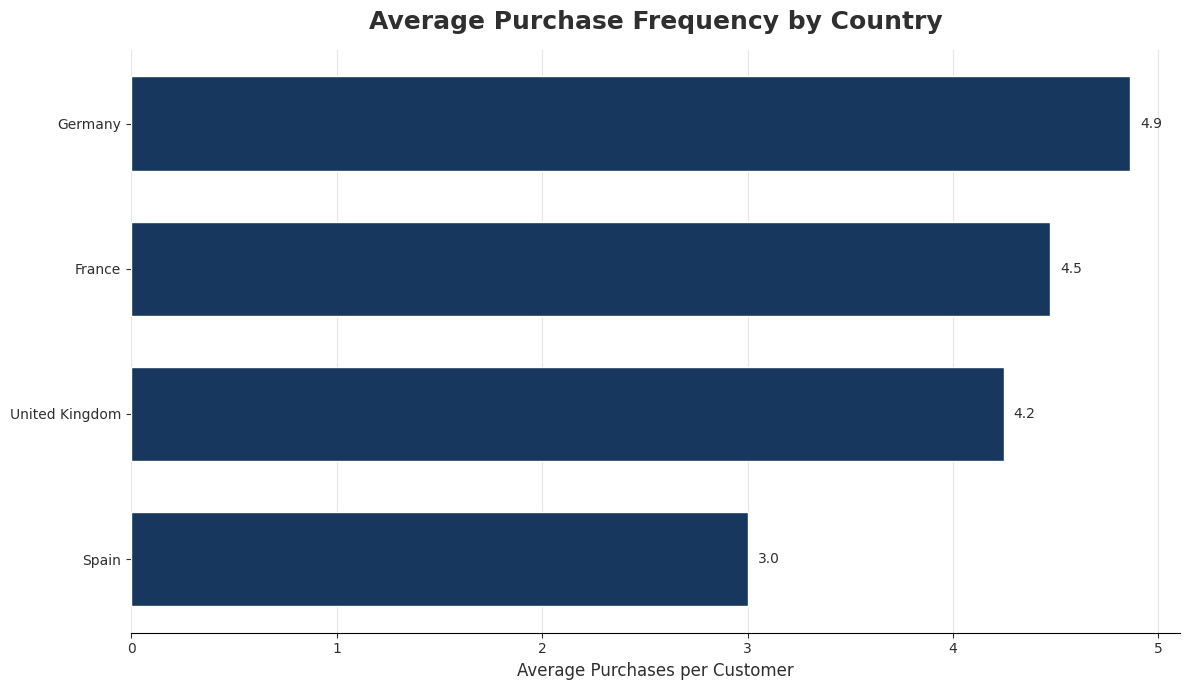

In [49]:
import matplotlib.pyplot as plt

# ---------------------------------------
# Executive Theme
# ---------------------------------------
PRIMARY_COLOR = "#17375E"
BACKGROUND = "#FFFFFF"
GRID_COLOR = "#E6E6E6"
TEXT_COLOR = "#2F2F2F"

fig, ax = plt.subplots(figsize=(12, 7))

# Horizontal Bars
bars = ax.barh(
    country_purchase_frequency["Country"],
    country_purchase_frequency["AveragePurchaseFrequency"],
    color=PRIMARY_COLOR,
    edgecolor="white",
    height=0.65
)

# Highest at Top
ax.invert_yaxis()

# Value Labels
for bar in bars:
    value = bar.get_width()

    ax.text(
        value + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}",
        va="center",
        ha="left",
        fontsize=10,
        color=TEXT_COLOR
    )

# Title
ax.set_title(
    "Average Purchase Frequency by Country",
    fontsize=18,
    fontweight="bold",
    color=TEXT_COLOR,
    pad=15
)

# Axis Labels
ax.set_xlabel(
    "Average Purchases per Customer",
    fontsize=12,
    color=TEXT_COLOR
)

ax.set_ylabel("")

# Grid
ax.grid(
    axis="x",
    color=GRID_COLOR,
    linewidth=0.8
)

ax.set_axisbelow(True)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

# Theme
ax.tick_params(axis="both", colors=TEXT_COLOR)

fig.patch.set_facecolor(BACKGROUND)
ax.set_facecolor(BACKGROUND)

plt.tight_layout()

plt.savefig(
    "../image/average_purchase_frequency_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Customer Engagement**
* Germany recorded the highest average purchase frequency at 4.9 completed purchases per customer, followed by France at 4.5 and the United Kingdom at 4.2, among countries with at least 30 identifiable customers.

**Customer Loyalty**
* Germany also recorded the highest repeat customer rate at 72.3%, followed by France (67.8%), Spain (66.7%), and the United Kingdom (65.5%).

**Strategic Recommendation**
* Germany combines the highest purchase frequency and repeat customer rate among qualifying markets. Despite having a smaller identifiable customer base of 94 customers, its strong engagement profile makes it a promising market for targeted retention and customer-development initiatives.

### 8. What customer purchasing behaviors can inform future marketing strategies?

In [68]:
# Basket size and order value 
invoice_behavior = (
    sales_df
    .drop_duplicates("InvoiceNo")
    .groupby("CustomerType", as_index=False)
    .agg(
        AverageBasketSize=("BasketSize", "mean"),
        AverageOrderValue=("InvoiceRevenue", "mean"),
    )
)

In [69]:
customer_frequency_behavior = (
    sales_df
    .loc[
        sales_df["CustomerID"].notna(),
        [
            "CustomerID",
            "CustomerType",
            "PurchaseFrequency",
        ],
    ]
    .drop_duplicates("CustomerID")
    .groupby("CustomerType", as_index=False)
    .agg(
        AveragePurchaseFrequency=(
            "PurchaseFrequency",
            "mean",
        )
    )
)

In [71]:
customer_behavior = (
    invoice_behavior
    .merge(
        customer_frequency_behavior,
        on="CustomerType",
        how="left",
    )
    .sort_values(
        "AverageOrderValue",
        ascending=False,
    )
)
customer_behavior

,CustomerType,AverageBasketSize,AverageOrderValue,AveragePurchaseFrequency
0,Guest Customer,79.733213,881.062140,<NA>
1,Registered Customer,18.098968,373.091145,4.271722


**Customer Purchasing Behavior**
* Guest Customers place substantially larger orders, with an average basket size of 79.7 items and an average order value of £881, compared with 18.1 items and £373 for Registered Customers.

**Customer Engagement**
* Registered Customers make an average of 4.3 completed purchases, indicating that their lower order values are offset by stronger repeat purchasing behavior. Purchase frequency cannot be measured for Guest Customers because individual customers cannot be identified.

**Strategic Recommendation**
* Develop targeted conversion strategies for high-value Guest Customers, such as account registration incentives and post-purchase engagement, to transform larger one-time transactions into identifiable long-term customer relationships.

# Executive Recommendations

| **Business Area**       | **Key Finding**                                                                                                                                                                                                                                                                 | **Business Impact**                                                                                                                                                                            | **Recommendation**                                                                                                                                                                                                         |
| ----------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Market Expansion**    | The United Kingdom generated approximately **84% of total revenue**, while the **Netherlands, EIRE, Germany, and France** were the strongest international markets by revenue.                                                                                                  | Revenue is highly concentrated in a single market, increasing dependency on the UK.                                                                                                            | Expand selectively in established high-performing European markets to diversify revenue while maintaining the strength of the UK market.                                                                                   |
| **Seasonal Demand**     | Revenue peaked at **£1.46M in November**, followed by **£1.18M in December**, indicating strong year-end demand.                                                                                                                                                                | Peak-season demand increases pressure on inventory, fulfilment, and operational capacity.                                                                                                      | Increase inventory, fulfilment capacity, staffing, and marketing readiness ahead of the **September–December** peak period.                                                                                                |
| **Product Strategy**    | High-volume and high-revenue products differ, with **DOTCOM POSTAGE (£206.2K)** leading revenue and **WORLD WAR 2 GLIDERS ASSTD DESIGNS (53.8K units)** leading sales volume.                                                                                                   | Product demand is distributed differently across revenue and volume measures, requiring different assortment priorities.                                                                       | Maintain availability of high-volume products while prioritizing high-revenue products for commercial and assortment planning.                                                                                             |
| **Order Management**    | Order cancellations resulted in approximately **£894K in unrealized revenue**, representing approximately **8.4% of gross sales revenue**.                                                                                                                                      | Cancellations materially reduce realized revenue and represent a potential source of revenue leakage.                                                                                          | Investigate the main causes of cancellations and improve inventory accuracy, order fulfilment, and exception management to reduce avoidable cancellations.                                                                 |
| **Customer Growth**     | **Registered Customers generated £8.28M (84.9%) of total revenue**, compared with **£1.47M (15.1%) from Guest Customers**.                                                                                                                                                      | Registered customers are the primary source of revenue and provide the strongest identifiable base for retention and repeat-purchase initiatives.                                              | Strengthen retention initiatives for registered customers while encouraging guest customers to register to enable future engagement and repeat-purchase activity.                                                          |
| **Customer Engagement** | Among countries with at least **30 identifiable customers**, **Germany recorded the highest average purchase frequency (4.9 completed purchases per customer)** and the highest repeat customer rate (**72.3%**).                                                               | Germany shows the strongest customer engagement among qualifying markets, although its customer base remains much smaller than the UK.                                                         | Prioritize targeted retention and customer-development initiatives in Germany while monitoring performance as the customer base expands.                                                                                   |
| **Marketing Strategy**  | Guest Customers place larger individual orders, with an average basket size of **79.7 items** and an average order value of **£881**, compared with **18.1 items** and **£373** for Registered Customers. Registered Customers make an average of **4.27 completed purchases**. | Guest and registered customers exhibit different purchasing behaviors: guests generate higher-value individual orders, while registered customers provide stronger repeat-purchase engagement. | Use targeted guest-to-registered conversion initiatives to build identifiable long-term customer relationships, while using personalized retention, cross-selling, and repeat-purchase campaigns for registered customers. |
